In [1]:
import xarray as xr
import shapely
import dask.array as da
import numpy as np
from numpy import random
import geopandas as gpd
import matplotlib.pyplot as plt
import sys

rng = np.random.default_rng()

In [ ]:
def opendrift_output_to_geodataframe(ncfile):
    
    # load opendrift output
    ds = xr.open_dataset(ncfile, chunks={})
    ds = ds.chunk({'trajectory': 100})

    # extract lon and lat and flatten
    lon = ds.lon.data.reshape(-1)
    lat = ds.lat.data.reshape(-1)

    # vectorized Shapely point constructor
    def make_points(lon_arr, lat_arr):
        return shapely.points(lon_arr, lat_arr)

    # apply with dask
    points = da.map_blocks(
        make_points,
        lon, lat,
        dtype=object
    )

    # extract and flatten needed variables from opendrift output
    status = ds.status.data.reshape(-1)
    age = ds.age_seconds.data.reshape(-1)/60./60.  # seconds --> hours
    z = ds.z.data.reshape(-1)
    origin = ds.origin_marker.data.reshape(-1)

    # trajectory and time indices
    traj_index = np.repeat(ds.trajectory.values, ds.time.size)+1
    time_index = np.tile(ds.time.values, ds.trajectory.size)

    # compute geometry and and other variables for geodataframe
    geom = points.compute()
    status_v = status.compute()
    age_v = age.compute()
    z_v = z.compute()
    origin_v = origin.compute()
    traj_v = traj_index
    time_v = time_index

    # build geodataframe
    coords = gpd.GeoDataFrame(
        {
            "traj": traj_v,
            "time": time_v,
            "status": status_v,
            "age_hours": age_v,
            "z": z_v,
            "origin_marker": origin_v,
        },
        geometry=geom,
        crs="EPSG:4326"
    )

    return coords

#%% read windfarms

shpfile = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
poly = gpd.read_file(shpfile)
#poly['fID'] = poly.index.to_numpy()+1

# %% read opendrift output

startID = 2 # id of release windfarm polygon
# startID = sys.argv[1] # id of release coast polygon
year = 2012
PLD = 5
month = 0

PLD_max = 60

outfol = '/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/seeding_from_farm/'
save_fol = '/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/test_sampling/'

if month == 0: # small farms, one simulation for the whole summer
    file = 'simulation_farm_{}_June_September_{}.nc'.format(startID, year)
else:
    if startID not in [11, 13]:
        file = 'simulation_farm_{}_June_September_{}_{}.nc'.format(startID, year, month) # medium farms, summer divided in two
    else :
        file = 'simulation_farm_{}_6_part_June_September_{}_{}.nc'.format(startID, year, month) # lower density of part. used for farms 11 and 13

# outfol = '/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/seeding_from_coast/'
# save_fol = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PLD}/from_coast_to_farm/'

# file = 'simulation_coast_{}_June_September_{}.nc'.format(startID, year)

ncfile = outfol + file
csvfile = save_fol + file.replace('.nc', f'_PD{PLD}_connectivity_test.csv')
coords = opendrift_output_to_geodataframe(ncfile)

# considering locations only within PLD (when set smaller than the maximum simulated PLD)
if PLD < PLD_max:
    arows = coords.age_hours < PLD*24+1
    coords = coords[arows]


In [8]:
save_fol = '/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/test_sampling/'
csvfile = save_fol + file.replace('.nc', f'_PD{PLD}_connectivity_test.csv')

row = poly.loc[poly['FarmID'] == startID]
area = int(row['Area_km2'].values[0]) # area (km²) 
sample_size = 5*area

# Get one row per trajectory (the seeding moment, age=0) to filter by depth and month
seeds = coords[coords['age_hours'] == 0].copy()

# Filter by depth and month of seeding
def sample_traj(df, depth, month):
    mask = (df['z'] == depth) & (df['time'].dt.month == month)
    pool = df.loc[mask, 'traj'].values
    return rng.choice(pool, size=sample_size, replace=False)

# June = month 6, July = month 7
random1_jun  = sample_traj(seeds, -1.0,  6)
random1_jul  = sample_traj(seeds, -1.0,  7)
random5_jun  = sample_traj(seeds, -5.0,  6)
random5_jul  = sample_traj(seeds, -5.0,  7)
random10_jun = sample_traj(seeds, -10.0, 6)
random10_jul = sample_traj(seeds, -10.0, 7)

random = np.concatenate([random1_jun, random1_jul,
                         random5_jun, random5_jul,
                         random10_jun, random10_jul])

coords_test = coords[coords['traj'].isin(random)]
print(coords_test)

           traj                time  status  age_hours     z  origin_marker  \
53352        20 2012-06-01 00:00:00     0.0        0.0  -1.0            2.0   
53353        20 2012-06-01 01:00:00     0.0        1.0  -1.0            2.0   
53354        20 2012-06-01 02:00:00     0.0        2.0  -1.0            2.0   
53355        20 2012-06-01 03:00:00     0.0        3.0  -1.0            2.0   
53356        20 2012-06-01 04:00:00     0.0        4.0  -1.0            2.0   
...         ...                 ...     ...        ...   ...            ...   
29471444  10496 2012-08-01 20:00:00     0.0      116.0 -10.0            2.0   
29471445  10496 2012-08-01 21:00:00     0.0      117.0 -10.0            2.0   
29471446  10496 2012-08-01 22:00:00     0.0      118.0 -10.0            2.0   
29471447  10496 2012-08-01 23:00:00     0.0      119.0 -10.0            2.0   
29471448  10496 2012-08-02 00:00:00     0.0      120.0 -10.0            2.0   

                           geometry  
53352       P

In [16]:
# %% compute spatial join
print('sjoin with coordinates and polygons')
# sjoin, and dropping time, origin_marker and status
# here sjoin changes FarmID.dtype to float (because it needs to store NaNs)
# --> needs to be changed back to int later
joined = gpd.sjoin(coords_test[['traj','age_hours','geometry']],poly[['FarmID','geometry']],
              how='left', predicate='intersects')
joined.drop(columns=['index_right'],inplace=True)

# age when reaching each polygon (individual trajectories)
age = joined.groupby(['traj','FarmID']).min(numeric_only=True).reset_index()
age['count'] = 1
# number of timesteps spent within each polygon (individual trajectories)
count = joined.groupby(['traj','FarmID']).nunique()
count.drop(columns=['geometry'],inplace=True)
count.columns = ['count']
count.reset_index(inplace=True)
# calculate number of trajectories reaching each polygon
Nto = count[['FarmID','traj']].groupby('FarmID').nunique()

print('creating connectivity matrix')
# reset index, rename columns, set datatype to integer
df = Nto.reset_index().rename(columns={'FarmID': 'to', 'traj': 'N'}).astype(int)
# add column for release location id
df['from'] = startID
# drop all other columns
df = df[['from','to','N']]
# calculate total number of released particles for calculating probability
Ntot = coords_test['traj'].nunique()
df['Ntot'] = Ntot
# probability of transport to each polygon
df['prob'] = df.N/Ntot

# %% save to csv
print('saving to '+csvfile)
df.to_csv(csvfile,sep=';',index=False,float_format='%.5f')

sjoin with coordinates and polygons
creating connectivity matrix
saving to /scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/test_sampling/simulation_farm_2_June_September_2012_PD5_connectivity_test.csv


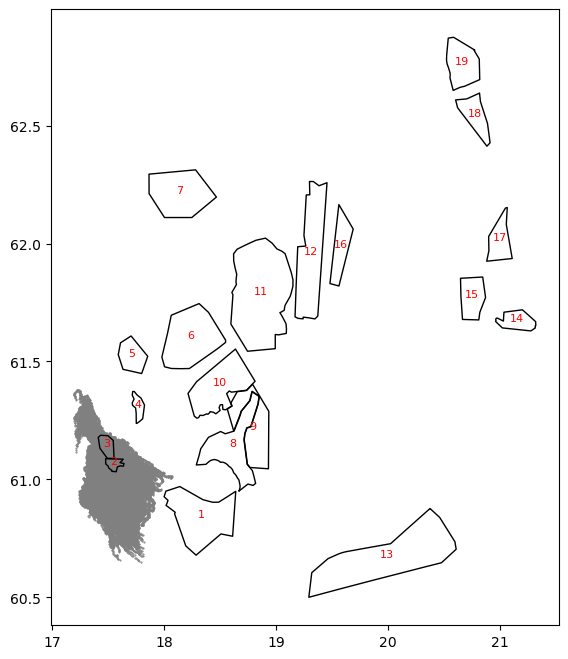

In [17]:
# %% plot to check

fig,ax = plt.subplots(1,1,figsize=(8, 8))
coords_test.plot(marker='.',markersize=1,color='grey',ax=ax)
poly.plot(edgecolor="black", facecolor="none",ax=ax)
for _, row in poly.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, str(row["FarmID"]), color='red', fontsize=8, ha="center")

plt.show()